<a href="https://colab.research.google.com/github/TipsyPanda/ComplexBridges/blob/main/ComplexBridge_features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML Anomaly Detection
- Import cleaned data
- feature dictionary per sensor type
- train models, by span x sensor type

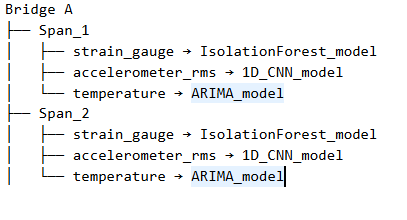



## 1) Setup

In [11]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import pyarrow
from datetime import timedelta
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import precision_recall_fscore_support, average_precision_score
import matplotlib.pyplot as plt
from typing import List, Tuple, Optional, Dict

# Matplotlib defaults (no explicit colors)
plt.rcParams["figure.figsize"] = (10, 4)


In [12]:
# Detect if running in Google Colab and mount Drive
IN_COLAB = False
try:
    from google.colab import drive  # type: ignore
    IN_COLAB = True
except Exception:
    drive = None
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive/')

base = Path("/content/drive/MyDrive/ComplexBridges") if IN_COLAB else Path("..")
DATA_PATH = base / "data"
ARTIFACT_DIR = base / "artifacts"
VALIDATION_DIR = ARTIFACT_DIR / "validation_results"


print("DATA_PATH       :", DATA_PATH)
print("ARTIFACT_DIR    :", ARTIFACT_DIR)
print("VALIDATION_DIR  :", VALIDATION_DIR)

DATA_PATH       : ..\data
ARTIFACT_DIR    : ..\artifacts
VALIDATION_DIR  : ..\artifacts\validation_results


## 2) Load with **DatetimeIndex**

In [13]:
df = pd.read_pickle(DATA_PATH / "DF_BridgeData_cleaned.pkl")
print(type(df.index), df.index.min(), "→", df.index.max())
print("Columns:", df.columns.tolist())
print(df.shape)
df.head()


<class 'pandas.core.indexes.datetimes.DatetimeIndex'> 2025-10-10 12:00:00 → 2025-10-10 12:29:59.900000
Columns: ['bridge_id', 'span_id', 'sensor_id', 'sensor_type', 'value', 'unit', 'traffic_load_proxy', 'rule_threshold', 'anomaly', 'anomaly_type']
(90000, 10)


,bridge_id,span_id,sensor_id,sensor_type,value,unit,traffic_load_proxy,rule_threshold,anomaly,anomaly_type
timestamp,,,,,,,,,,
2025-10-10 12:00:00,BRIDGE_A01,SPAN_1,SG_001,strain_gauge,118.571847,microstrain,0.5,200.00,0,NaN
2025-10-10 12:00:00,BRIDGE_A01,SPAN_2,SG_002,strain_gauge,128.986727,microstrain,0.5,200.00,0,NaN
2025-10-10 12:00:00,BRIDGE_A01,SPAN_1,ACC_101,accelerometer_rms,0.020849,g,0.5,0.05,0,NaN
2025-10-10 12:00:00,BRIDGE_A01,SPAN_2,ACC_102,accelerometer_rms,0.015481,g,0.5,0.05,0,NaN
2025-10-10 12:00:00,BRIDGE_A01,SPAN_2,TMP_201,temperature,21.884280,C,0.5,35.00,0,NaN


## 3) Feature Map

In [14]:
# Feature map per sensor_type (controls what we keep later)
feature_dict = {
    "strain_gauge":      ["f_mean","f_std","f_rms","f_p2p","f_slope","fft_low","fft_mid","fft_high"],
    "accelerometer_rms": ["f_rms","fft_centroid","fft_entropy","fft_dominant"],
    "temperature":       ["f_mean","f_slope","ctx_tl_mean"],
}

# Frequency bands for FFT (Hz) – tune to your sampling rate & physics
BANDS = {
    "strain_gauge":      [(0.0, 5.0), (5.0, 20.0), (20.0, 100.0)],   # low/mid/high
    "accelerometer_rms": [(0.5, 5.0), (5.0, 25.0), (25.0, 100.0)],
}


## 4) Helper Classes

In [15]:
def infer_base_freq(idx: pd.DatetimeIndex) -> str:
    g = pd.infer_freq(idx)
    if g:
        return g
    # fallback: median step in milliseconds
    deltas = idx.to_series().diff().dropna().dt.total_seconds()
    ms = max(int(np.median(deltas)*1000), 1)
    return f"{ms}L"  # 'L' = ms

def resample_fixed(ts: pd.DataFrame, how: str = "ffill") -> Tuple[pd.DataFrame, float]:
    """Return fixed-rate series and the *sampling rate* (Hz)."""
    ts = ts.sort_index()
    base = infer_base_freq(ts.index)
    out = ts.resample(base).ffill() if how == "ffill" else ts.resample(base).mean()
    # sampling rate from base freq
    if base.endswith("L"):  # milliseconds
        sr = 1000.0 / float(base[:-1])
    elif base.endswith("S"):  # seconds
        sr = 1.0 / float(base[:-1])
    else:
        # very coarse fallback
        step = out.index.to_series().diff().dropna().dt.total_seconds().median()
        sr = 0.0 if step is None or step == 0 else 1.0/step
    return out, sr

def window_iter(idx: pd.DatetimeIndex, window="30s", step="15s"):
    w = pd.to_timedelta(window)
    s = pd.to_timedelta(step)
    t0, t1 = idx.min(), idx.max()
    cur = t0
    while cur + w <= t1:
        yield (cur, cur + w)
        cur += s

def linear_slope(y: np.ndarray) -> float:
    if y.size < 2: return 0.0
    x = np.arange(y.size)
    return float(np.polyfit(x, y, 1)[0])

def spectral_features(y: np.ndarray, sr: float, bands: List[Tuple[float,float]]):
    """
    Returns:
      band_powers: list per band
      centroid_hz: float
      entropy: float (0..~)
      dominant_hz: float
    """
    if y.size < 4 or sr <= 0:
        n_b = len(bands)
        return [0.0]*n_b, 0.0, 0.0, 0.0

    # remove mean to focus on oscillatory content
    x = y - np.mean(y)

    # FFT (real)
    spec = np.fft.rfft(x)
    freqs = np.fft.rfftfreq(x.size, d=1.0/sr)
    power = np.abs(spec)**2

    # band powers
    band_powers = []
    for lo, hi in bands:
        m = (freqs >= lo) & (freqs < hi)
        band_powers.append(float(power[m].sum()))

    # dominant frequency
    if power.size > 0:
        k = int(np.argmax(power))
        dominant_hz = float(freqs[k])
    else:
        dominant_hz = 0.0

    # spectral centroid & entropy
    p_sum = power.sum()
    if p_sum > 0:
        p_norm = power / p_sum
        centroid_hz = float((p_norm * freqs).sum())
        # Shannon entropy over normalized spectrum (avoid log(0))
        eps = 1e-12
        entropy = float(-(p_norm * np.log(p_norm + eps)).sum())
    else:
        centroid_hz, entropy = 0.0, 0.0

    return band_powers, centroid_hz, entropy, dominant_hz


## Core: compute window features for one stream

In [16]:
def compute_window_features(
    ts: pd.DataFrame,
    sensor_type: str,
    window,
    step,
    use_context=True
) -> pd.DataFrame:
    """
    ts: DataFrame for a single sensor stream with columns:
        ['value', 'traffic_load_proxy', 'rule_threshold', 'anomaly', 'temperature'(optional)]
        and a DatetimeIndex.
    Returns: features DataFrame with 't_center' and feature columns.
    """
    assert isinstance(ts.index, pd.DatetimeIndex), "Expect DatetimeIndex"
    ts = ts.sort_index()

    # fixed-rate + sampling rate (Hz)
    ts_r, sr = resample_fixed(ts, how="ffill")

    rows = []
    for t_start, t_end in window_iter(ts_r.index, window=window, step=step):
        win = ts_r.loc[t_start:t_end]
        if len(win) < 3:
            continue

        v = win['value'].to_numpy()
        # time-domain
        f_mean = float(np.mean(v))
        f_std  = float(np.std(v, ddof=1)) if len(v)>1 else 0.0
        f_rms  = float(np.sqrt(np.mean(v**2)))
        f_p2p  = float(np.max(v) - np.min(v))
        f_slope= linear_slope(v)

        # freq-domain (only for accel/strain)
        f_fft_low=f_fft_mid=f_fft_high=0.0
        f_fft_centroid=f_fft_entropy=f_fft_dom=0.0
        if sensor_type in ("strain_gauge","accelerometer_rms"):
            bands = BANDS.get(sensor_type, [])
            bp, cen, ent, dom = spectral_features(v, sr, bands)
            # map to fields
            if len(bp) >= 3:
                f_fft_low, f_fft_mid, f_fft_high = bp[:3]
            elif len(bp) == 2:
                f_fft_low, f_fft_mid = bp
            elif len(bp) == 1:
                f_fft_low = bp[0]
            f_fft_centroid, f_fft_entropy, f_fft_dom = cen, ent, dom

        # context
        ctx_tl_mean = None
        if use_context and 'traffic_load_proxy' in win.columns:
            ctx_tl_mean = float(win['traffic_load_proxy'].mean())

        # weak label (optional)
        label = None
        if 'anomaly' in win.columns:
            label = int((win['anomaly'] == 1).any())

        # record
        t_center = t_start + (pd.to_timedelta(window)/2)
        row = {
            't_center': t_center,
            'f_mean': f_mean, 'f_std': f_std, 'f_rms': f_rms,
            'f_p2p': f_p2p, 'f_slope': f_slope,
            'fft_low': f_fft_low, 'fft_mid': f_fft_mid, 'fft_high': f_fft_high,
            'fft_centroid': f_fft_centroid, 'fft_entropy': f_fft_entropy, 'fft_dominant': f_fft_dom,
            'ctx_tl_mean': ctx_tl_mean
        }
        if label is not None:
            row['label_rule'] = label
        rows.append(row)

    feats = pd.DataFrame(rows).sort_values('t_center').reset_index(drop=True)
    return feats


##3) Assemble feature matrix per sensor_type

In [17]:
def build_features_for_type(df_all, sensor_type, window, step):
    """
    Filters df_all for `sensor_type`, groups by sensor_id, computes features,
    concatenates, and keeps only the columns defined in `feature_dict[sensor_type]`.
    """
    cols_needed = ['value', 'span_id', 'traffic_load_proxy', 'rule_threshold', 'anomaly']
    df_type = df_all[df_all['sensor_type'] == sensor_type].copy()
    out = []

    for sid, g in df_type.groupby('sensor_id'):
        ts = g[cols_needed].copy()
        ts.index = g.index  # ensure DatetimeIndex
        feats = compute_window_features(ts, sensor_type=sensor_type, window=window, step=step)
        feats['sensor_id'] = sid
        feats['sensor_type'] = sensor_type
        feats['span_id'] = g['span_id'].iloc[0]  # directly take from group
        out.append(feats)

    if not out:
        return pd.DataFrame()

    F = pd.concat(out, ignore_index=True)

    # include span_id in output
    keep = ['t_center', 'sensor_id', 'sensor_type', 'span_id'] + feature_dict.get(sensor_type, [])
    if 'label_rule' in F.columns:
        keep += ['label_rule']
    keep = [c for c in keep if c in F.columns]

    return F[keep].sort_values(['sensor_id', 't_center']).reset_index(drop=True)



##4) Run: build all three matrices and scale

In [18]:
# Build per type
feats_strain = build_features_for_type(df, "strain_gauge",      window="5s", step="3s")
feats_accel  = build_features_for_type(df, "accelerometer_rms", window="5s", step="3s")
feats_temp   = build_features_for_type(df, "temperature",       window="5min", step="2min30s")  # temp can be slower

print("strain:", feats_strain.shape, "accel:", feats_accel.shape, "temp:", feats_temp.shape)

# ───────────────────────────────────────────────────────────────────────────────
# Fit scalers *per sensor_type* and save both scalers + feature files
# ───────────────────────────────────────────────────────────────────────────────
from sklearn.preprocessing import RobustScaler
import joblib, os

scalers: Dict[str, RobustScaler] = {}
scaled: Dict[str, pd.DataFrame] = {}

for s_type, F in [
    ("strain_gauge", feats_strain),
    ("accelerometer_rms", feats_accel),
    ("temperature", feats_temp)
]:
    if F.empty:
        print(f"[{s_type}] skipped – no data")
        continue

    # Columns to scale
    feat_cols = [c for c in F.columns if c not in ('t_center','sensor_id','sensor_type','label_rule','span_id')]

    # Fit scaler & transform
    scaler = RobustScaler().fit(F[feat_cols])
    Xs = scaler.transform(F[feat_cols])

    Fs = F.copy()
    Fs[feat_cols] = Xs

    # Store in dictionaries
    scalers[s_type] = scaler
    scaled[s_type] = Fs

    # Save scaler
    sc_path = f"{ARTIFACT_DIR}/scaler/scaler_{s_type}.joblib"
    joblib.dump(scaler, sc_path)

    # Save features (original + scaled)
    base = ARTIFACT_DIR / "features" / f"feats_{s_type}"
    F.to_parquet(f"{base}.parquet", index=False)
    F.to_csv(f"{base}.csv", index=False)
    Fs.to_parquet(f"{base}_scaled.parquet", index=False)
    Fs.to_csv(f"{base}_scaled.csv", index=False)

    print(f"[{s_type}] scaled={Fs.shape}  → saved: {sc_path}, {base}_scaled.(parquet/csv)")



strain: (1198, 13) accel: (1198, 9) temp: (10, 8)
[strain_gauge] scaled=(1198, 13)  → saved: ..\artifacts/scaler/scaler_strain_gauge.joblib, ..\artifacts\features\feats_strain_gauge_scaled.(parquet/csv)
[accelerometer_rms] scaled=(1198, 9)  → saved: ..\artifacts/scaler/scaler_accelerometer_rms.joblib, ..\artifacts\features\feats_accelerometer_rms_scaled.(parquet/csv)
[temperature] scaled=(10, 8)  → saved: ..\artifacts/scaler/scaler_temperature.joblib, ..\artifacts\features\feats_temperature_scaled.(parquet/csv)


## 3) Select a single stream for modeling (per `sensor_id`)

Working stream: strain_gauge SG_001 rows: 18000


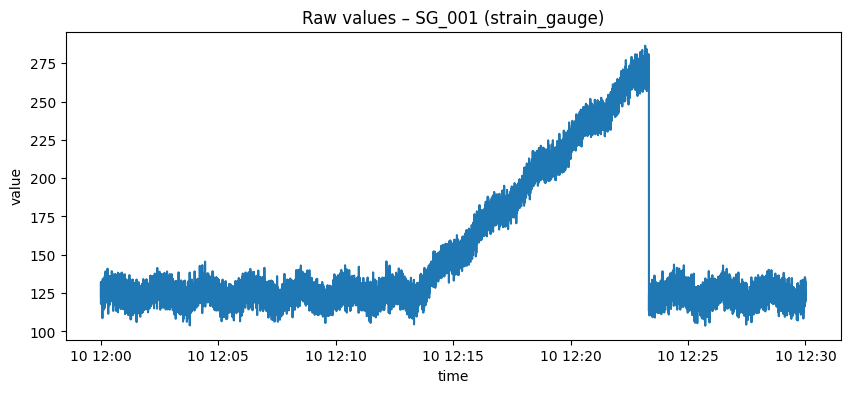

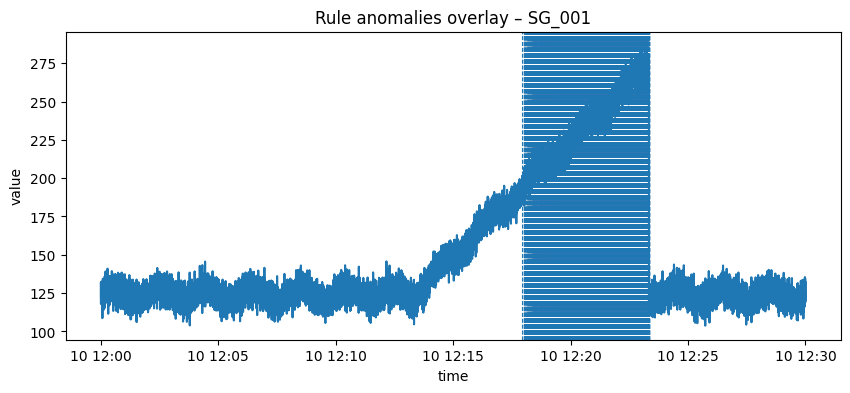

In [19]:

# Pick the first available sensor_id within the first sensor_type (customize as needed)
first_type = df['sensor_type'].dropna().unique()[0]
first_sensor = df.loc[df['sensor_type']==first_type, 'sensor_id'].dropna().unique()[0]

sub = df[(df['sensor_type']==first_type) & (df['sensor_id']==first_sensor)].copy()
sub = sub.sort_index()
print("Working stream:", first_type, first_sensor, "rows:", len(sub))

# Quick raw plot
fig = plt.figure()
plt.plot(sub.index, sub['value'])
plt.title(f"Raw values – {first_sensor} ({first_type})")
plt.xlabel("time"); plt.ylabel("value")
plt.show()

# Optional: overlay rule anomalies as vertical lines (if present)
if 'anomaly' in sub.columns:
    fig = plt.figure()
    plt.plot(sub.index, sub['value'])
    t_anom = sub.index[sub['anomaly']==1]
    for t in t_anom:
        plt.axvline(t, linestyle='--', linewidth=0.8)
    plt.title(f"Rule anomalies overlay – {first_sensor}")
    plt.xlabel("time"); plt.ylabel("value")
    plt.show()


## 4) Rolling-window feature engineering (uses index)

In [20]:

def infer_base_freq(idx: pd.DatetimeIndex) -> str:
    """Infer a base frequency string from a DatetimeIndex."""
    # Try pandas inference first
    guessed = pd.infer_freq(idx)
    if guessed is not None:
        return guessed
        print(guessed)
    # Fallback to median delta in milliseconds
    deltas = idx.to_series().diff().dropna().dt.total_seconds()
    if len(deltas) == 0:
        return "1S"
    ms = int(np.median(deltas) * 1000)
    ms = max(ms, 1)  # at least 1ms
    return f"{ms}L"  # 'L' = milliseconds

def make_rolling_features_index(ts: pd.DataFrame, window: str = '30s', step: str = '15s'):
    """
    Build rolling-window features assuming ts.index is a DatetimeIndex.
    Keeps time as the index; returns a DataFrame with 't_center' as a datetime column.
    """
    if not isinstance(ts.index, pd.DatetimeIndex):
        raise TypeError("Expected a DatetimeIndex")
    ts = ts.sort_index()

    base_freq = infer_base_freq(ts.index)
    # Resample to fixed grid, forward-fill short gaps
    ts = ts.resample(base_freq).ffill()

    start, end = ts.index.min(), ts.index.max()
    out = []
    cur = start
    w = pd.to_timedelta(window)
    s = pd.to_timedelta(step)

    while cur + w <= end:
        win = ts.loc[cur:cur+w]
        if len(win) < 3:
            cur += s
            continue

        v = win['value'].values
        mean = float(np.mean(v))
        std = float(np.std(v, ddof=1)) if len(v) > 1 else 0.0
        rms = float(np.sqrt(np.mean(v**2)))
        p2p = float(np.max(v) - np.min(v))
        skew = float(pd.Series(v).skew()) if len(v) > 2 else 0.0
        kurt = float(pd.Series(v).kurtosis()) if len(v) > 3 else 0.0
        x = np.arange(len(v))
        slope = float(np.polyfit(x, v, 1)[0]) if len(v) > 1 else 0.0
        dv = np.diff(v)
        adiff_mean = float(np.mean(np.abs(dv))) if len(dv) else 0.0

        ctx = {}
        if 'traffic_load_proxy' in win.columns:
            tl = win['traffic_load_proxy'].values
            ctx['ctx_tl_mean'] = float(np.mean(tl))
            ctx['ctx_tl_std']  = float(np.std(tl, ddof=1)) if len(tl)>1 else 0.0
        if 'rule_threshold' in win.columns:
            ctx['ctx_rule_thr'] = float(np.median(win['rule_threshold']))

        label = None
        if 'anomaly' in win.columns:
            label = int((win['anomaly'] == 1).any())

        t_center = cur + w/2
        row = {
            't_center': t_center,
            'f_mean': mean, 'f_std': std, 'f_rms': rms, 'f_p2p': p2p,
            'f_skew': skew, 'f_kurt': kurt, 'f_slope': slope, 'f_adiff_mean': adiff_mean,
            **ctx
        }
        if label is not None:
            row['label_rule'] = label
        out.append(row)

        cur += s

    feats = pd.DataFrame(out).sort_values('t_center').reset_index(drop=True)
    return feats

feats = make_rolling_features_index(
    sub[['value','traffic_load_proxy','rule_threshold','anomaly']].copy(),
    window='30s', step='15s'
)
print(feats.shape)
feats.head()


(118, 13)


,t_center,f_mean,f_std,f_rms,f_p2p,f_skew,f_kurt,f_slope,f_adiff_mean,ctx_tl_mean,ctx_tl_std,ctx_rule_thr,label_rule
0,2025-10-10 12:00:15,126.658658,5.125310,126.761970,32.285725,-0.192222,0.193634,0.016330,5.402789,0.818113,0.154629,200.0,0
1,2025-10-10 12:00:30,127.476108,5.127490,127.578845,29.445191,-0.294861,0.166361,-0.000120,5.614491,0.949874,0.044363,200.0,0
2,2025-10-10 12:00:45,126.552713,5.147081,126.656992,25.979810,-0.050644,-0.171488,-0.009421,5.859216,0.818113,0.154629,200.0,0
3,2025-10-10 12:01:00,124.418993,5.043529,124.520835,27.749312,0.230286,0.226950,-0.017983,5.591404,0.500000,0.214149,200.0,0
4,2025-10-10 12:01:15,122.157222,5.010743,122.259605,29.463011,0.064628,0.247391,-0.007486,5.524889,0.181887,0.154629,200.0,0


## 5) Temporal split and scaling

In [21]:

cut = int(len(feats) * 0.7)
train = feats.iloc[:cut].copy()
test  = feats.iloc[cut:].copy()

feature_cols = [c for c in feats.columns if c.startswith('f_') or c.startswith('ctx_')]
label_col = 'label_rule' if 'label_rule' in feats.columns else None

from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
Xs_tr = scaler.fit_transform(train[feature_cols])
Xs_te = scaler.transform(test[feature_cols])

import joblib
joblib.dump(scaler, os.path.join(ARTIFACT_DIR, "scaler.joblib"))
print("Saved:", os.path.join(ARTIFACT_DIR, "scaler.joblib"))


Saved: ..\artifacts\scaler.joblib


## 6) Isolation Forest (unsupervised)

In [22]:

from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=300,
    contamination='auto',
    random_state=42,
    n_jobs=-1
)
iso.fit(Xs_tr)

score_tr = iso.decision_function(Xs_tr)
score_te = iso.decision_function(Xs_te)

import joblib
joblib.dump(iso, os.path.join(ARTIFACT_DIR, "isoforest.pkl"))
print("Saved:", os.path.join(ARTIFACT_DIR, "isoforest.pkl"))


Saved: ..\artifacts\isoforest.pkl


## 7) Threshold calibration

In [23]:

import numpy as np, json

def pick_threshold(scores, quantile=0.005):
    return float(np.quantile(scores, quantile))

thr = pick_threshold(score_tr, quantile=0.005)
print("Chosen threshold:", thr)

with open(os.path.join(ARTIFACT_DIR, "threshold.json"), "w") as f:
    json.dump({"score_threshold": thr}, f)
print("Saved:", os.path.join(ARTIFACT_DIR, "threshold.json"))


Chosen threshold: -0.09627266609583994
Saved: ..\artifacts\threshold.json


## 8) Evaluation & visuals

AP: 1.000  Precision: 1.000  Recall: 0.417  F1: 0.588


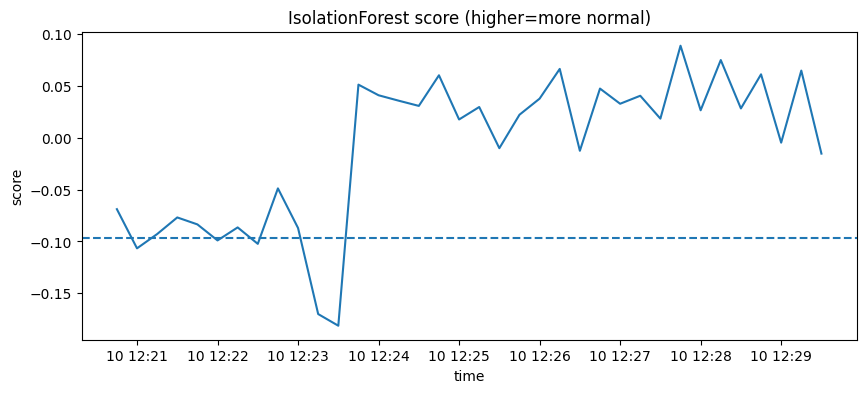

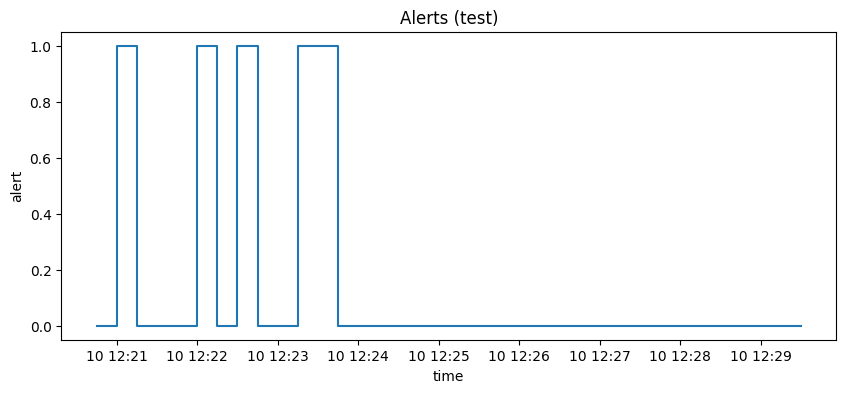

In [24]:

from sklearn.metrics import precision_recall_fscore_support, average_precision_score
import matplotlib.pyplot as plt

alerts_te = (score_te < thr).astype(int)

if label_col is not None and label_col in test.columns:
    y_true = test[label_col].values
    anomaly_score_te = -score_te
    ap = average_precision_score(y_true, anomaly_score_te)
    p, r, f1, _ = precision_recall_fscore_support(y_true, alerts_te, average='binary', zero_division=0)
    print(f"AP: {ap:.3f}  Precision: {p:.3f}  Recall: {r:.3f}  F1: {f1:.3f}")
else:
    print("No labels available; showing score plots only.")

# Score timeline
fig = plt.figure()
plt.plot(test['t_center'], score_te)
plt.axhline(thr, linestyle='--')
plt.title("IsolationForest score (higher=more normal)")
plt.xlabel("time"); plt.ylabel("score")
plt.show()

# Alerts (binary)
fig = plt.figure()
plt.plot(test['t_center'], alerts_te, drawstyle='steps-post')
plt.title("Alerts (test)")
plt.xlabel("time"); plt.ylabel("alert")
plt.show()


## 9) Mini scoring loop (DatetimeIndex pipeline)

In [25]:

events = []
for t, s, a in zip(test['t_center'], score_te, (score_te < thr).astype(int)):
    if a == 1:
        events.append({"t": str(t), "event": "ALERT", "score": float(s)})
len(events), events[:5]


(5,
 [{'t': '2025-10-10 12:21:00',
   'event': 'ALERT',
   'score': -0.10662848740170594},
  {'t': '2025-10-10 12:22:00',
   'event': 'ALERT',
   'score': -0.09900459889421032},
  {'t': '2025-10-10 12:22:30',
   'event': 'ALERT',
   'score': -0.10229669810224928},
  {'t': '2025-10-10 12:23:15',
   'event': 'ALERT',
   'score': -0.16990673693912628},
  {'t': '2025-10-10 12:23:30',
   'event': 'ALERT',
   'score': -0.18114191368111987}])

## 10) Notes & next steps
- Resampling is driven by the DatetimeIndex (no `timestamp` column).
- Extend features with FFT band powers for vibration streams.
- Consider per-sensor models for tighter boundaries.
- Add drift monitoring with rolling median/MAD of scores.
- Wire artifacts into a Streamlit dashboard.
